<a href="https://colab.research.google.com/github/pankajmehta13891/Worldbank-github.io/blob/main/Final_Mini_project_World_bank_Indicators.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Word Bank Indicators PANDAS project**

#Analysis of World Bank WDI Data for India, China, and the USA

In this notebook we analyze key development indicators – GDP growth (annual %), Total population, Life expectancy at birth, and CO₂ emissions (metric tons per capita) – for India, China, and the United States using the provided World Bank WDI dataset (wide format). We perform data cleaning and filtering without reshaping to long form, then apply grouping, aggregation, ranking, and percentage-change operations. Finally, we visualize trends using line, bar, and scatter plots. Each section includes Python code and a clear explanation of the Pandas operations, with relevant references.

# 1. Data Loading and Cleaning (Wide Format)

In the WDI wide-format CSV, each row corresponds to a country-indicator pair, and columns include metadata plus one column per year (e.g. 1960, 1961, ..., 2020). The snippet above reads the file into a DataFrame and prints its shape and first few columns. We ensure column names are clean (no leading/trailing spaces) and confirm the year columns are present. For example, the first few columns might be ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', ...].

Explanation: We use pd.read_csv to load the data. In a wide-format dataset like this, the year columns are currently strings. We may keep them as strings or convert to integers for convenience. Data cleaning here might include trimming whitespace from column names (e.g. df.columns = df.columns.str.strip()) and handling any missing values (df.dropna() or df.fillna()) if necessary. Wide format means we do not melt or pivot unless explicitly needed.

In [62]:


import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/pankajmehta13891/Worldbank-github.io/refs/heads/main/WB_WDI_WIDEF%20-selected.csv")
df.head()

,ACTION,FREQ,REF_AREA,INDICATOR,SEX,AGE,URBANISATION,UNIT_MEASURE,UNIT_TYPE,DECIMALS,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,I,A,JPN,WB_WDI_NY_GDP_FRST_RT_ZS,_T,_T,_T,PT_GDP,RATIO,2,...,0.017410,0.017122,0.028961,0.024870,0.023852,0.023554,0.028703,NaN,NaN,NaN
1,I,A,ISR,WB_WDI_NY_GDP_PCAP_CD,_T,_T,_T,USD,CUR,2,...,36213.104150,37671.538910,41138.470960,42362.665280,44250.631360,44575.571900,52270.904020,54949.621560,52003.720070,54176.684440
2,I,A,THA,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,RATIO,2,...,3.134047,3.435158,4.177681,4.222870,2.114558,-6.050038,1.552166,2.580379,2.017751,2.541821
3,I,A,RUS,WB_WDI_NY_GDP_DEFL_KD_ZG,_T,_T,_T,PC_A,RATIO,2,...,7.249736,2.844223,5.349815,9.997977,3.263133,0.898246,18.209101,18.184689,7.998571,9.275671
4,I,A,THA,WB_WDI_NE_CON_TOTL_ZS,_T,_T,_T,PT_GDP,RATIO,2,...,68.465854,66.874638,65.229267,65.062480,65.943160,70.842487,70.474856,72.283981,74.097911,74.898275


In [63]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [64]:
#the code df.shape returns a tuple representing the dimensions of the DataFrame df.
#The output (294796, 106) means that the DataFrame df has 294,796 rows and 106 columns.


print(f"Dataset shape: {df.shape}")
print("Sample columns:", df.columns[:6].tolist())
print(df.columns)

Dataset shape: (2336, 92)
Sample columns: ['ACTION', 'FREQ', 'REF_AREA', 'INDICATOR', 'SEX', 'AGE']
Index(['ACTION', 'FREQ', 'REF_AREA', 'INDICATOR', 'SEX', 'AGE', 'URBANISATION',
       'UNIT_MEASURE', 'UNIT_TYPE', 'DECIMALS', 'DATABASE_ID', 'TIME_FORMAT',
       'UNIT_MULT', 'DATA_SOURCE', 'OBS_CONF', 'OBS_STATUS', 'FREQ_LABEL',
       'REF_AREA_LABEL', 'INDICATOR_LABEL', 'URBANISATION_LABEL',
       'AGG_METHOD_LABEL', 'UNIT_TYPE_LABEL', 'DECIMALS_LABEL',
       'TIME_FORMAT_LABEL', 'UNIT_MULT_LABEL', 'OBS_STATUS_LABEL',
       'OBS_CONF_LABEL', '1960', '1961', '1962', '1963', '1964', '1965',
       '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974',
       '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983',
       '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992',
       '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001',
       '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010',
  

# consise summary of the dataframe

The df.info() method in pandas is used to print a concise summary of a DataFrame. This summary includes important information like the index dtype, column dtypes, non-null values, and memory usage. It's a very useful function for a quick overview of your data's structure and completeness.

The df.describe() method generates descriptive statistics of the DataFrame columns. For numerical columns, it provides statistics like count, mean, standard deviation, min, max, and quartile values. This gives you a quick statistical summary and helps you understand the distribution and central tendency of your data.

The code df.isnull().sum() is a very useful command in Pandas for understanding the completeness of your dataset. It works by first creating a boolean DataFrame where True indicates a missing (NaN) value and False indicates a non-missing value. Then, .sum() counts the True values for each column, effectively showing you the total number of missing values in each column of your df DataFrame.

In [65]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2336 entries, 0 to 2335
Data columns (total 92 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ACTION              2336 non-null   object 
 1   FREQ                2336 non-null   object 
 2   REF_AREA            2336 non-null   object 
 3   INDICATOR           2336 non-null   object 
 4   SEX                 2336 non-null   object 
 5   AGE                 2336 non-null   object 
 6   URBANISATION        2336 non-null   object 
 7   UNIT_MEASURE        2336 non-null   object 
 8   UNIT_TYPE           2336 non-null   object 
 9   DECIMALS            2336 non-null   int64  
 10  DATABASE_ID         2336 non-null   object 
 11  TIME_FORMAT         2336 non-null   object 
 12  UNIT_MULT           2336 non-null   int64  
 13  DATA_SOURCE         2336 non-null   object 
 14  OBS_CONF            2336 non-null   object 
 15  OBS_STATUS          2336 non-null   object 
 16  FREQ_L

In [66]:
df.describe()

,DECIMALS,UNIT_MULT,1960,1961,1962,1963,1964,1965,1966,1967,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
count,2336.0,2336.0,5.300000e+02,6.330000e+02,6.370000e+02,6.390000e+02,6.410000e+02,6.570000e+02,6.580000e+02,6.580000e+02,...,2.207000e+03,2.207000e+03,2.147000e+03,2.143000e+03,2.117000e+03,2.099000e+03,2.089000e+03,1.884000e+03,1.732000e+03,1.510000e+03
mean,2.0,0.0,3.013614e+11,2.784767e+11,2.978410e+11,3.232447e+11,3.578929e+11,3.720389e+11,4.099243e+11,4.520069e+11,...,3.932704e+12,4.099965e+12,4.415103e+12,4.610664e+12,4.777571e+12,4.783170e+12,5.158585e+12,6.024042e+12,6.979319e+12,8.917424e+12
std,0.0,0.0,3.566365e+12,3.641221e+12,3.938861e+12,4.280644e+12,4.785725e+12,5.014011e+12,5.560553e+12,6.187666e+12,...,6.865524e+13,7.156767e+13,7.580573e+13,7.874240e+13,8.049629e+13,8.098982e+13,8.646377e+13,9.462853e+13,1.022178e+14,1.164166e+14
min,2.0,0.0,-1.680000e+10,-2.010000e+10,-1.720000e+10,-1.790000e+10,-2.170000e+10,-2.690000e+10,-2.970000e+10,-4.070000e+10,...,-5.330000e+11,-5.790000e+11,-2.330000e+12,-1.830000e+12,-1.680000e+12,-2.460000e+12,-4.980000e+12,-5.200000e+12,-5.300000e+12,-6.480000e+12
25%,2.0,0.0,1.132224e+01,7.330909e+00,6.671531e+00,7.922806e+00,7.362590e+00,7.267744e+00,6.865283e+00,6.886660e+00,...,1.869784e+00,1.744840e+00,2.018820e+00,1.987435e+00,1.908432e+00,1.558879e+00,2.910821e+00,4.616115e+00,4.078943e+00,3.524026e+00
50%,2.0,0.0,3.670684e+01,2.379922e+01,2.341911e+01,2.368486e+01,2.461552e+01,2.522404e+01,2.557969e+01,2.485999e+01,...,1.943127e+01,1.965725e+01,1.996473e+01,1.986971e+01,2.078459e+01,2.078359e+01,2.139916e+01,2.691027e+01,3.037323e+01,3.579936e+01
75%,2.0,0.0,6.276683e+03,1.589714e+03,1.525776e+03,1.642928e+03,1.728137e+03,1.689069e+03,1.731203e+03,1.668624e+03,...,9.476282e+01,9.642614e+01,9.964708e+01,9.999002e+01,1.014695e+02,1.052381e+02,1.101716e+02,1.616707e+02,2.486079e+02,1.391555e+04
max,2.0,0.0,7.350000e+13,8.230000e+13,8.970000e+13,9.730000e+13,1.090000e+14,1.150000e+14,1.270000e+14,1.410000e+14,...,1.840000e+15,1.900000e+15,1.960000e+15,2.030000e+15,2.070000e+15,2.060000e+15,2.220000e+15,2.320000e+15,2.410000e+15,2.560000e+15


In [67]:
df.isnull().sum()


,0
ACTION,0
FREQ,0
REF_AREA,0
INDICATOR,0
SEX,0
...,...
2020,237
2021,247
2022,452
2023,604


In [68]:
df["INDICATOR"].unique()

array(['WB_WDI_NY_GDP_FRST_RT_ZS', 'WB_WDI_NY_GDP_PCAP_CD',
       'WB_WDI_NY_GDP_MKTP_KD_ZG', 'WB_WDI_NY_GDP_DEFL_KD_ZG',
       'WB_WDI_NE_CON_TOTL_ZS', 'WB_WDI_BX_TRF_PWKR_DT_GD_ZS',
       'WB_WDI_SE_XPD_TOTL_GD_ZS', 'WB_WDI_CM_MKT_LCAP_GD_ZS',
       'WB_WDI_TG_VAL_TOTL_GD_ZS', 'WB_WDI_BM_KLT_DINV_WD_GD_ZS',
       'WB_WDI_BG_GSR_NFSV_GD_ZS', 'WB_WDI_NE_GDI_FTOT_ZS',
       'WB_WDI_NY_GDP_PCAP_KD', 'WB_WDI_EG_EGY_PRIM_PP_KD',
       'WB_WDI_NY_GDP_NGAS_RT_ZS', 'WB_WDI_NV_IND_TOTL_ZS',
       'WB_WDI_GC_NLD_TOTL_GD_ZS', 'WB_WDI_MS_MIL_XPND_GD_ZS',
       'WB_WDI_NE_EXP_GNFS_ZS', 'WB_WDI_GC_XPN_TOTL_GD_ZS',
       'WB_WDI_SL_GDP_PCAP_EM_KD', 'WB_WDI_NY_GDS_TOTL_ZS',
       'WB_WDI_NV_SRV_TOTL_ZS', 'WB_WDI_NY_GDP_PCAP_CN',
       'WB_WDI_NY_GDP_MKTP_PP_KD', 'WB_WDI_BN_CAB_XOKA_GD_ZS',
       'WB_WDI_NY_GDP_MKTP_CN', 'WB_WDI_NY_GDP_DEFL_KD_ZG_AD',
       'WB_WDI_CM_MKT_TRAD_GD_ZS', 'WB_WDI_EG_GDP_PUSE_KO_PP',
       'WB_WDI_SE_XPD_SECO_PC_ZS', 'WB_WDI_EN_GHG_CO2_RT_GDP_KD',
       'WB

In [69]:
df.groupby("REF_AREA")["1960"].mean().sort_values(ascending=False).head(10)

,1960
REF_AREA,
JPN,6.082893e+12
KOR,9.775022e+11
USA,4.825882e+11
NAC,3.560833e+11
IND,2.406938e+11
MMR,2.299657e+11
DEU,1.894182e+11
MEX,1.124136e+11
ITA,9.186364e+10


In [70]:
# Top 10 most common indicators
df["INDICATOR"].value_counts().head(10)

,count
INDICATOR,
WB_WDI_EG_EGY_PRIM_PP_KD,30
WB_WDI_NY_GDP_PCAP_CD,29
WB_WDI_NY_GDP_MKTP_KD_ZG,29
WB_WDI_NY_GDP_DEFL_KD_ZG,29
WB_WDI_NY_GDP_FRST_RT_ZS,29
WB_WDI_NV_IND_TOTL_ZS,29
WB_WDI_BX_TRF_PWKR_DT_GD_ZS,29
WB_WDI_TG_VAL_TOTL_GD_ZS,29
WB_WDI_SE_XPD_TOTL_GD_ZS,29


# Glance at the dataset columns

***Advanced***


In [71]:
# --- Cell 2: Quick glance (rows & columns) ---
# Show first rows
display(df.head(10))

# Full column list (helps you understand structure)
for i, c in enumerate(df.columns, 1):
    print(f"{i:03d}. {c}")

# Basic info
print("\nDtypes and non-null counts:")
print(df.dtypes)
print("\nNull counts per column (top 30):")
print(df.isnull().sum().sort_values(ascending=False).head(30))


,ACTION,FREQ,REF_AREA,INDICATOR,SEX,AGE,URBANISATION,UNIT_MEASURE,UNIT_TYPE,DECIMALS,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,I,A,JPN,WB_WDI_NY_GDP_FRST_RT_ZS,_T,_T,_T,PT_GDP,RATIO,2,...,0.017410,0.017122,0.028961,0.024870,0.023852,0.023554,0.028703,NaN,NaN,NaN
1,I,A,ISR,WB_WDI_NY_GDP_PCAP_CD,_T,_T,_T,USD,CUR,2,...,36213.104150,37671.538910,41138.470960,42362.665280,44250.631360,44575.571900,52270.904020,54949.621560,52003.720070,54176.684440
2,I,A,THA,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,RATIO,2,...,3.134047,3.435158,4.177681,4.222870,2.114558,-6.050038,1.552166,2.580379,2.017751,2.541821
3,I,A,RUS,WB_WDI_NY_GDP_DEFL_KD_ZG,_T,_T,_T,PC_A,RATIO,2,...,7.249736,2.844223,5.349815,9.997977,3.263133,0.898246,18.209101,18.184689,7.998571,9.275671
4,I,A,THA,WB_WDI_NE_CON_TOTL_ZS,_T,_T,_T,PT_GDP,RATIO,2,...,68.465854,66.874638,65.229267,65.062480,65.943160,70.842487,70.474856,72.283981,74.097911,74.898275
5,I,A,FRA,WB_WDI_BX_TRF_PWKR_DT_GD_ZS,_T,_T,_T,PT_GDP,RATIO,2,...,1.041870,1.035973,1.035402,1.020556,1.056406,1.132348,1.100530,1.170522,1.200839,1.226897
6,I,A,GRC,WB_WDI_BX_TRF_PWKR_DT_GD_ZS,_T,_T,_T,PT_GDP,RATIO,2,...,0.261779,0.216038,0.200054,0.229584,0.326247,0.319488,0.315554,0.275508,0.223070,0.219111
7,I,A,MUS,WB_WDI_SE_XPD_TOTL_GD_ZS,_T,_T,_T,PT_GDP,RATIO,2,...,4.758470,4.882070,4.878870,4.674480,4.541950,4.352440,4.671510,4.840860,4.567640,4.089800
8,I,A,KOR,WB_WDI_CM_MKT_LCAP_GD_ZS,_T,_T,_T,PT_GDP,RATIO,2,...,79.988950,79.444054,103.600239,77.495704,84.797346,124.776480,114.227599,91.393870,106.678084,83.048808
9,I,A,LKA,WB_WDI_TG_VAL_TOTL_GD_ZS,_T,_T,_T,PT_GDP,RATIO,2,...,34.647897,33.514692,34.269601,36.128104,35.817375,30.950166,37.417836,42.347884,34.308795,31.945213


001. ACTION
002. FREQ
003. REF_AREA
004. INDICATOR
005. SEX
006. AGE
007. URBANISATION
008. UNIT_MEASURE
009. UNIT_TYPE
010. DECIMALS
011. DATABASE_ID
012. TIME_FORMAT
013. UNIT_MULT
014. DATA_SOURCE
015. OBS_CONF
016. OBS_STATUS
017. FREQ_LABEL
018. REF_AREA_LABEL
019. INDICATOR_LABEL
020. URBANISATION_LABEL
021. AGG_METHOD_LABEL
022. UNIT_TYPE_LABEL
023. DECIMALS_LABEL
024. TIME_FORMAT_LABEL
025. UNIT_MULT_LABEL
026. OBS_STATUS_LABEL
027. OBS_CONF_LABEL
028. 1960
029. 1961
030. 1962
031. 1963
032. 1964
033. 1965
034. 1966
035. 1967
036. 1968
037. 1969
038. 1970
039. 1971
040. 1972
041. 1973
042. 1974
043. 1975
044. 1976
045. 1977
046. 1978
047. 1979
048. 1980
049. 1981
050. 1982
051. 1983
052. 1984
053. 1985
054. 1986
055. 1987
056. 1988
057. 1989
058. 1990
059. 1991
060. 1992
061. 1993
062. 1994
063. 1995
064. 1996
065. 1997
066. 1998
067. 1999
068. 2000
069. 2001
070. 2002
071. 2003
072. 2004
073. 2005
074. 2006
075. 2007
076. 2008
077. 2009
078. 2010
079. 2011
080. 2012
081. 2013


In [72]:
# Unique indicator codes and their human labels
indicator_map = df[['INDICATOR', 'INDICATOR_LABEL']].drop_duplicates().reset_index(drop=True)
display(indicator_map.head(10))

# Count how many different indicators
print("Distinct indicators:", indicator_map.shape[0])

# Top indicators by number of rows (useful for choosing common indicators)
indicator_counts = df['INDICATOR'].value_counts().reset_index()
indicator_counts.columns = ['INDICATOR', 'rows']
display(indicator_counts.head(10))


,INDICATOR,INDICATOR_LABEL
0,WB_WDI_NY_GDP_FRST_RT_ZS,Forest rents (% of GDP)
1,WB_WDI_NY_GDP_PCAP_CD,GDP per capita (current US$)
2,WB_WDI_NY_GDP_MKTP_KD_ZG,GDP growth (annual %)
3,WB_WDI_NY_GDP_DEFL_KD_ZG,"Inflation, GDP deflator (annual %)"
4,WB_WDI_NE_CON_TOTL_ZS,Final consumption expenditure (% of GDP)
5,WB_WDI_BX_TRF_PWKR_DT_GD_ZS,"Personal remittances, received (% of GDP)"
6,WB_WDI_SE_XPD_TOTL_GD_ZS,"Government expenditure on education, total (% ..."
7,WB_WDI_CM_MKT_LCAP_GD_ZS,Market capitalization of listed domestic compa...
8,WB_WDI_TG_VAL_TOTL_GD_ZS,Merchandise trade (% of GDP)
9,WB_WDI_BM_KLT_DINV_WD_GD_ZS,"Foreign direct investment, net outflows (% of ..."


Distinct indicators: 85


,INDICATOR,rows
0,WB_WDI_EG_EGY_PRIM_PP_KD,30
1,WB_WDI_NY_GDP_PCAP_CD,29
2,WB_WDI_NY_GDP_MKTP_KD_ZG,29
3,WB_WDI_NY_GDP_DEFL_KD_ZG,29
4,WB_WDI_NY_GDP_FRST_RT_ZS,29
5,WB_WDI_NV_IND_TOTL_ZS,29
6,WB_WDI_BX_TRF_PWKR_DT_GD_ZS,29
7,WB_WDI_TG_VAL_TOTL_GD_ZS,29
8,WB_WDI_SE_XPD_TOTL_GD_ZS,29
9,WB_WDI_NY_GDP_PCAP_KD,29


In [73]:
#Detect year columns programmatically
year_cols = [c for c in df.columns if c.isdigit()]
year_cols[:10]

#print("Years found:", min(int(c) for c in year_cols), "to", max(int(c) for c in year_cols))

['1960',
 '1961',
 '1962',
 '1963',
 '1964',
 '1965',
 '1966',
 '1967',
 '1968',
 '1969']

In [74]:
# Example: pick an indicator code (replace with one from indicator_map)
code = "WB_WDI_NY_GDP_MKTP_KD_ZG"   # e.g. GDP growth (annual %)
country = "IND"                  # use REF_AREA_LABEL value

# Filter by label or code:
rows = df[(df['INDICATOR'] == code) & (df['REF_AREA'] == country)]
display(rows.head())


,ACTION,FREQ,REF_AREA,INDICATOR,SEX,AGE,URBANISATION,UNIT_MEASURE,UNIT_TYPE,DECIMALS,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
535,I,A,IND,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,RATIO,2,...,7.996254,8.256306,6.795383,6.453851,3.871437,-5.777725,9.689592,7.609365,9.190755,6.494766


# Working with the dataset

**1. Filtering by Indicator and Country**

In [75]:
# Suppose you filtered for a single indicator first:


# Average by country (over all years)

avg_by_country = (
    df
    .groupby("REF_AREA")[year_cols]   # select all year columns
    .mean(numeric_only=True)          # mean across rows for each year
    .mean(axis=1)                     # mean across all years per country
    .sort_values(ascending=False)
    .head(10)
)

display(avg_by_country)

#singl year
df.groupby("REF_AREA")["1960"].mean().sort_values(ascending=False).head(10)


,0
REF_AREA,
KOR,2.890554e+13
JPN,1.686358e+13
RUS,2.561399e+12
IND,2.257695e+12
MMR,1.518027e+12
CHN,1.455074e+12
USA,9.652189e+11
NAC,7.269379e+11
ARG,5.333319e+11


,1960
REF_AREA,
JPN,6.082893e+12
KOR,9.775022e+11
USA,4.825882e+11
NAC,3.560833e+11
IND,2.406938e+11
MMR,2.299657e+11
DEU,1.894182e+11
MEX,1.124136e+11
ITA,9.186364e+10


In [76]:
INDIA=df[df["REF_AREA"] == "IND"]
india_by_year = INDIA[year_cols].mean(numeric_only=True)
display(india_by_year.head(10))

,0
1960,2.406938e+11
1961,2.282029e+11
1962,2.354857e+11
1963,2.501571e+11
1964,2.694229e+11
1965,2.630771e+11
1966,2.633686e+11
1967,2.845543e+11
1968,2.949629e+11
1969,3.160486e+11


Below code  calculates a general average value for each country across all numerical year columns. It first groups the DataFrame by 'REF_AREA' (country code), then calculates the mean of all year columns for each country. Finally, it takes the mean of these year averages for each country to get a single average value, sorts them in descending order, and displays the top 10. This gives a very broad sense of which countries have generally higher indicator values across the entire dataset and all years.

df.groupby("REF_AREA")["1960"].mean()...: This is a more specific calculation. It groups the DataFrame by 'REF_AREA' and then directly calculates the mean only for the '1960' column for each country. It then sorts these averages in descending order and shows the top 10 countries for that specific year.

**The WDI dataset stores time-series values in wide format, where each year is a separate column. To perform time-based analysis (such as grouping by year), the dataset was reshaped into long format using pd.melt(). This enables standard Pandas operations such as groupby("Year"), aggregation, and plotting of trends over time.**

Parameter	Meaning
 id_vars	Columns that identify each row (country, indicator name, etc.)

 value_vars	Columns to unpivot (years)

 var_name="Year"	Name of new column storing year

 value_name="Value"	Name of new column storing values

In [77]:
#MELT
indicator_code = "WB_WDI_NY_GDP_MKTP_KD_ZG"  # example: GDP growth

# Identify year columns
year_cols = [c for c in df.columns if c.isdigit()]

one_indicator = df[df["INDICATOR"] == indicator_code]
display(one_indicator.head())

# Melt ONLY this indicator
long_one_indicator = one_indicator.melt(
    id_vars=[c for c in df.columns if c not in year_cols],
    value_vars=year_cols,
    var_name="Year",
    value_name="Value"
)

long_one_indicator["Year"] = long_one_indicator["Year"].astype(int)

display(long_one_indicator.head())




,ACTION,FREQ,REF_AREA,INDICATOR,SEX,AGE,URBANISATION,UNIT_MEASURE,UNIT_TYPE,DECIMALS,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
2,I,A,THA,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,RATIO,2,...,3.134047,3.435158,4.177681,4.222870,2.114558,-6.050038,1.552166,2.580379,2.017751,2.541821
16,I,A,IRL,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,RATIO,2,...,24.623986,1.222717,10.108858,7.688659,4.972880,7.153695,16.258188,7.511139,-2.536374,2.599467
56,I,A,GRC,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,RATIO,2,...,-0.228302,-0.031795,1.473125,2.064672,2.277181,-9.196231,8.654498,5.521986,2.135911,2.086574
92,I,A,MEX,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,RATIO,2,...,2.702323,1.772493,1.871729,1.972082,-0.392691,-8.354035,6.048483,3.709757,3.353541,1.427428
180,I,A,GBR,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,RATIO,2,...,2.140406,2.206520,3.023222,1.551331,1.256299,-10.047897,8.543112,5.149704,0.271650,1.126423


,ACTION,FREQ,REF_AREA,INDICATOR,SEX,AGE,URBANISATION,UNIT_MEASURE,UNIT_TYPE,DECIMALS,...,URBANISATION_LABEL,AGG_METHOD_LABEL,UNIT_TYPE_LABEL,DECIMALS_LABEL,TIME_FORMAT_LABEL,UNIT_MULT_LABEL,OBS_STATUS_LABEL,OBS_CONF_LABEL,Year,Value
0,I,A,THA,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,RATIO,2,...,Total,Not Applicable,Ratio,Two,Annual,Units,Normal value,Public,1960,NaN
1,I,A,IRL,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,RATIO,2,...,Total,Not Applicable,Ratio,Two,Annual,Units,Normal value,Public,1960,NaN
2,I,A,GRC,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,RATIO,2,...,Total,Not Applicable,Ratio,Two,Annual,Units,Normal value,Public,1960,NaN
3,I,A,MEX,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,RATIO,2,...,Total,Not Applicable,Ratio,Two,Annual,Units,Normal value,Public,1960,NaN
4,I,A,GBR,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,RATIO,2,...,Total,Not Applicable,Ratio,Two,Annual,Units,Normal value,Public,1960,NaN


This code snippet focuses on analyzing data for India from the long_one_indicator DataFrame, which you previously created by melting a specific indicator. First, it filters long_one_indicator to select only the rows where the 'REF_AREA' (country code) is 'IND', storing this subset in india_indicator_long. Then, it groups this India-specific data by 'Year' and calculates the mean() of the 'Value' column for each year, resulting in the india_by_year series. Finally, it displays the first 10 entries of this series, showing India's average indicator value for the earliest years present.

In [78]:
india_indicator_long = long_one_indicator[long_one_indicator["REF_AREA"] == "IND"]

india_by_year = india_indicator_long.groupby("Year")["Value"].mean()

display(india_by_year.head(10))


,Value
Year,
1960,NaN
1961,3.722743
1962,2.931128
1963,5.994353
1964,7.452950
1965,-2.635770
1966,-0.055329
1967,7.825963
1968,3.387929


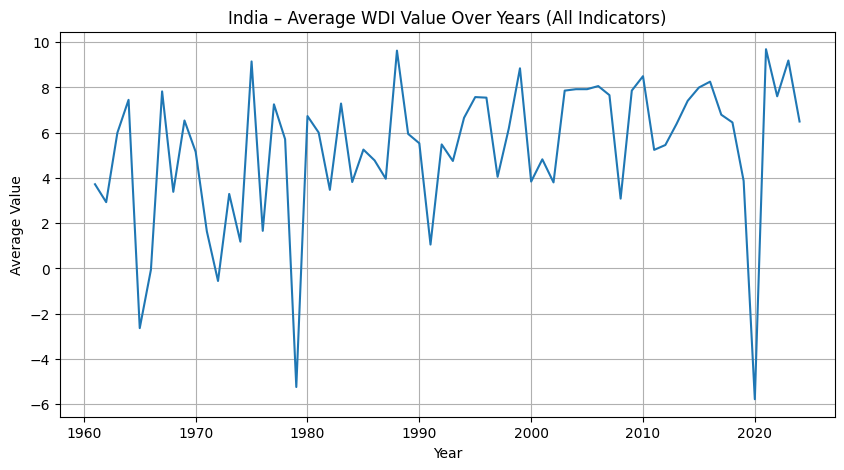

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
india_by_year.plot()
plt.title("India – Average WDI Value Over Years (All Indicators)")
plt.xlabel("Year")
plt.ylabel("Average Value")
plt.grid(True)
plt.show()


**Working without Melt function()**

In [80]:
df = pd.read_csv("https://raw.githubusercontent.com/pankajmehta13891/Worldbank-github.io/refs/heads/main/WB_WDI_WIDEF%20-selected.csv")
df.head()

,ACTION,FREQ,REF_AREA,INDICATOR,SEX,AGE,URBANISATION,UNIT_MEASURE,UNIT_TYPE,DECIMALS,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,I,A,JPN,WB_WDI_NY_GDP_FRST_RT_ZS,_T,_T,_T,PT_GDP,RATIO,2,...,0.017410,0.017122,0.028961,0.024870,0.023852,0.023554,0.028703,NaN,NaN,NaN
1,I,A,ISR,WB_WDI_NY_GDP_PCAP_CD,_T,_T,_T,USD,CUR,2,...,36213.104150,37671.538910,41138.470960,42362.665280,44250.631360,44575.571900,52270.904020,54949.621560,52003.720070,54176.684440
2,I,A,THA,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,RATIO,2,...,3.134047,3.435158,4.177681,4.222870,2.114558,-6.050038,1.552166,2.580379,2.017751,2.541821
3,I,A,RUS,WB_WDI_NY_GDP_DEFL_KD_ZG,_T,_T,_T,PC_A,RATIO,2,...,7.249736,2.844223,5.349815,9.997977,3.263133,0.898246,18.209101,18.184689,7.998571,9.275671
4,I,A,THA,WB_WDI_NE_CON_TOTL_ZS,_T,_T,_T,PT_GDP,RATIO,2,...,68.465854,66.874638,65.229267,65.062480,65.943160,70.842487,70.474856,72.283981,74.097911,74.898275


In [81]:
indicator_code = "WB_WDI_NY_GDP_MKTP_KD_ZG"  # replace with your indicator code
one_indicator = df[df["INDICATOR"] == indicator_code]

display(one_indicator.head())

,ACTION,FREQ,REF_AREA,INDICATOR,SEX,AGE,URBANISATION,UNIT_MEASURE,UNIT_TYPE,DECIMALS,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
2,I,A,THA,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,RATIO,2,...,3.134047,3.435158,4.177681,4.222870,2.114558,-6.050038,1.552166,2.580379,2.017751,2.541821
16,I,A,IRL,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,RATIO,2,...,24.623986,1.222717,10.108858,7.688659,4.972880,7.153695,16.258188,7.511139,-2.536374,2.599467
56,I,A,GRC,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,RATIO,2,...,-0.228302,-0.031795,1.473125,2.064672,2.277181,-9.196231,8.654498,5.521986,2.135911,2.086574
92,I,A,MEX,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,RATIO,2,...,2.702323,1.772493,1.871729,1.972082,-0.392691,-8.354035,6.048483,3.709757,3.353541,1.427428
180,I,A,GBR,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,RATIO,2,...,2.140406,2.206520,3.023222,1.551331,1.256299,-10.047897,8.543112,5.149704,0.271650,1.126423


In [82]:
year_cols = [c for c in df.columns if c.isdigit()]

In [83]:
INDIA = one_indicator[one_indicator["REF_AREA"] == "IND"]

In [84]:
# Average across all rows for India for each year (if multiple breakdown rows exist)
india_by_year = INDIA[year_cols].mean(numeric_only=True)

display(india_by_year.head(10))

,0
1960,NaN
1961,3.722743
1962,2.931128
1963,5.994353
1964,7.452950
1965,-2.635770
1966,-0.055329
1967,7.825963
1968,3.387929
1969,6.539700


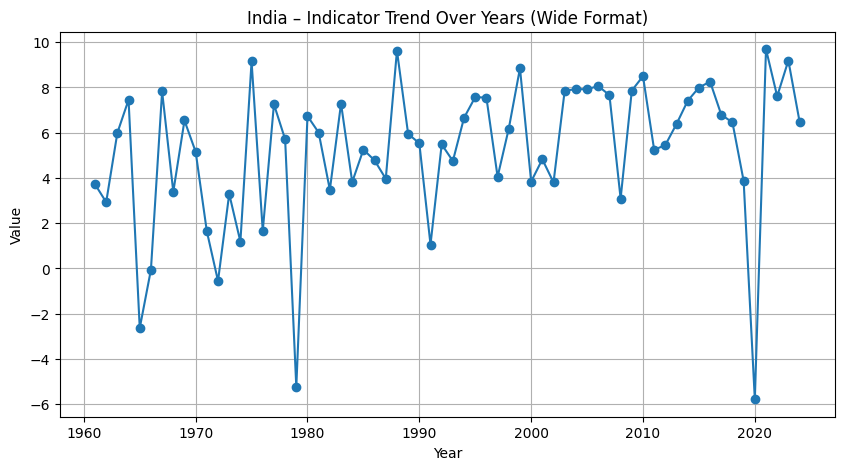

In [85]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
india_by_year.astype(float).plot(marker='o')
plt.title("India – Indicator Trend Over Years (Wide Format)")
plt.xlabel("Year")
plt.ylabel("Value")
plt.grid(True)
plt.show()

# Compare Multiple Countries and Basic Operation


1.The dataset was filtered to selected countries using Boolean indexing. Since the WDI file may contain multiple rows per country–indicator, values were aggregated using groupby("REF_AREA") and averaged across duplicate rows. Only year columns were selected to ensure numeric aggregation. This produced a wide-format time series table for comparing India, China, and the United States over time.

2.The WDI dataset has a natural hierarchical structure: each country contains multiple indicators observed over time. This hierarchy was modeled using a Pandas MultiIndex with (REF_AREA, INDICATOR) as the index and years as columns. This structure enables intuitive slicing by country or indicator and supports panel-style time-series analysis without reshaping the dataset.

3.# Slice multiple countries

In [86]:
countries = ["IND", "CHN", "USA"]

compare = (
    one_indicator[one_indicator["REF_AREA"].isin(countries)]
    .groupby("REF_AREA")[year_cols]
    .mean(numeric_only=True)
)

display(compare.head())

,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
REF_AREA,,,,,,,,,,,,,,,,,,,,,
CHN,NaN,-27.270000,-5.580000,10.300000,18.18000,16.95000,10.650000,-5.770000,-4.100000,16.9400,...,6.978780,6.775556,6.891266,6.756718,6.068502,2.340188,8.570085,3.134189,5.414843,4.977357
IND,NaN,3.722743,2.931128,5.994353,7.45295,-2.63577,-0.055329,7.825963,3.387929,6.5397,...,7.996254,8.256306,6.795383,6.453851,3.871437,-5.777725,9.689592,7.609365,9.190755,6.494766
USA,NaN,2.300000,6.100000,4.400000,5.80000,6.40000,6.500000,2.500000,4.800000,3.1000,...,2.945550,1.819451,2.457622,2.966505,2.583825,-2.163029,6.055053,2.512375,2.887556,2.793001


In [87]:
# MultiIndex by (Country, Indicator)
mi_wide = one_indicator.set_index(["REF_AREA", "INDICATOR"])[year_cols]

display(mi_wide.head())


,,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
REF_AREA,INDICATOR,,,,,,,,,,,,,,,,,,,,,
THA,WB_WDI_NY_GDP_MKTP_KD_ZG,NaN,5.362146,7.554254,7.999831,6.830996,8.181662,11.122518,8.615982,8.122270,6.550660,...,3.134047,3.435158,4.177681,4.222870,2.114558,-6.050038,1.552166,2.580379,2.017751,2.541821
IRL,WB_WDI_NY_GDP_MKTP_KD_ZG,NaN,5.016169,3.216444,4.744634,3.785962,1.933450,0.893093,5.785704,8.243929,5.863855,...,24.623986,1.222717,10.108858,7.688659,4.972880,7.153695,16.258188,7.511139,-2.536374,2.599467
GRC,WB_WDI_NY_GDP_MKTP_KD_ZG,NaN,13.203839,0.364812,11.844867,9.409677,10.768011,6.494501,5.669486,7.203718,11.563668,...,-0.228302,-0.031795,1.473125,2.064672,2.277181,-9.196231,8.654498,5.521986,2.135911,2.086574
MEX,WB_WDI_NY_GDP_MKTP_KD_ZG,NaN,5.000000,4.664415,8.106887,11.905481,7.100000,6.096139,5.854925,9.423279,3.418620,...,2.702323,1.772493,1.871729,1.972082,-0.392691,-8.354035,6.048483,3.709757,3.353541,1.427428
GBR,WB_WDI_NY_GDP_MKTP_KD_ZG,NaN,2.701314,1.098696,4.859545,5.594811,2.130333,1.567450,2.775738,5.472693,1.939138,...,2.140406,2.206520,3.023222,1.551331,1.256299,-10.047897,8.543112,5.149704,0.271650,1.126423


In [88]:
# All years for India
mi_wide.loc[("IND", indicator_code)]

# Slice multiple countries
mi_wide.loc[["IND", "USA"]]

,,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
REF_AREA,INDICATOR,,,,,,,,,,,,,,,,,,,,,
IND,WB_WDI_NY_GDP_MKTP_KD_ZG,NaN,3.722743,2.931128,5.994353,7.45295,-2.63577,-0.055329,7.825963,3.387929,6.5397,...,7.996254,8.256306,6.795383,6.453851,3.871437,-5.777725,9.689592,7.609365,9.190755,6.494766
USA,WB_WDI_NY_GDP_MKTP_KD_ZG,NaN,2.300000,6.100000,4.400000,5.80000,6.40000,6.500000,2.500000,4.800000,3.1000,...,2.945550,1.819451,2.457622,2.966505,2.583825,-2.163029,6.055053,2.512375,2.887556,2.793001


In [89]:
#Normalize by country (row-wise operation)
normalized = mi_wide.div(mi_wide.mean(axis=1), axis=0)
display(normalized.head())

,,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
REF_AREA,INDICATOR,,,,,,,,,,,,,,,,,,,,,
THA,WB_WDI_NY_GDP_MKTP_KD_ZG,NaN,0.973433,1.371384,1.452273,1.240085,1.485283,2.019160,1.564128,1.474501,1.189194,...,0.568949,0.623612,0.758408,0.766611,0.383873,-1.098312,0.281777,0.468437,0.366299,0.461437
IRL,WB_WDI_NY_GDP_MKTP_KD_ZG,NaN,1.008863,0.646898,0.954251,0.761441,0.388860,0.179621,1.163634,1.658037,1.179352,...,4.952430,0.245915,2.033116,1.546360,1.000157,1.438767,3.269883,1.510657,-0.510121,0.522811
GRC,WB_WDI_NY_GDP_MKTP_KD_ZG,NaN,4.746085,0.131131,4.257606,3.382283,3.870533,2.334431,2.037882,2.589357,4.156530,...,-0.082063,-0.011429,0.529511,0.742141,0.818527,-3.305561,3.110836,1.984863,0.767748,0.750014
MEX,WB_WDI_NY_GDP_MKTP_KD_ZG,NaN,1.411788,1.317033,2.289041,3.361603,2.004739,1.721291,1.653183,2.660735,0.965273,...,0.763022,0.500477,0.528497,0.556832,-0.110879,-2.358825,1.707835,1.047478,0.946898,0.403045
GBR,WB_WDI_NY_GDP_MKTP_KD_ZG,NaN,1.186127,0.482429,2.133790,2.456640,0.935413,0.688255,1.218806,2.403019,0.851461,...,0.939836,0.968867,1.327474,0.681178,0.551632,-4.411957,3.751217,2.261197,0.119280,0.494604


In [90]:
#Year-over-year change
# Ensure year_cols are strings to match DataFrame columns

yoy_change = INDIA[year_cols].pct_change(axis=1) * 100
display(yoy_change.head())

#string_year_cols = [str(y) for y in year_cols]

#yoy_change = INDIA[string_year_cols].pct_change(axis=1) * 100
display(yoy_change.head())

/tmp/ipython-input-355/4102038732.py:4: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  yoy_change = INDIA[year_cols].pct_change(axis=1) * 100


,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
535,NaN,NaN,-21.264291,104.506722,24.332848,-135.36546,-97.90085,-14244.473176,-56.709108,93.029428,...,7.908343,3.252169,-17.694622,-5.025943,-40.01354,-249.239799,-267.706026,-21.468679,20.782154,-29.33371


,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
535,NaN,NaN,-21.264291,104.506722,24.332848,-135.36546,-97.90085,-14244.473176,-56.709108,93.029428,...,7.908343,3.252169,-17.694622,-5.025943,-40.01354,-249.239799,-267.706026,-21.468679,20.782154,-29.33371


# **RANKING COUNTRIES**


1.   Rank countries by a specific year
2.   Rank Countries for Several Specific Years
3.  Rank Countries by Average Across Multiple Years
4. Produce a Rank Table (Actual Rank Numbers Per Year)
5. Plot: Top 5 Countries Over Time (Wide Format)
6.Plot: Top 5 Countries Over Time (Wide Format)



In [91]:
#Rank countries by a specific year
rank_2020 = (
    one_indicator.groupby("REF_AREA")["2020"]
    .mean(numeric_only=True)
    .sort_values(ascending=False)
)

display(rank_2020.head(10))


,2020
REF_AREA,
IRL,7.153695
CHN,2.340188
KOR,-0.700242
NOR,-1.278172
ISR,-2.021615
USA,-2.163029
NAC,-2.388620
FIN,-2.491036
RUS,-2.653655


In [92]:
#rank for multiple years

years = ["2018", "2019", "2020", "2021", "2022"]

rank_multi_years = (
    one_indicator
    .groupby("REF_AREA")[years]
    .mean(numeric_only=True)          # average across breakdown rows
    .sort_values(by="2020", ascending=False)  # sort by one reference year
)

display(rank_multi_years.head(10))


,2018,2019,2020,2021,2022
REF_AREA,,,,,
IRL,7.688659,4.972880,7.153695,16.258188,7.511139
CHN,6.756718,6.068502,2.340188,8.570085,3.134189
KOR,3.176116,2.313802,-0.700242,4.612968,2.727565
NOR,0.828932,1.123747,-1.278172,3.908687,3.246229
ISR,4.003899,3.710496,-2.021615,9.388374,6.263263
USA,2.966505,2.583825,-2.163029,6.055053,2.512375
NAC,2.947809,2.530125,-2.388620,6.046692,2.640583
FIN,1.192978,1.349738,-2.491036,2.676346,0.763042
RUS,2.807245,2.198076,-2.653655,5.866492,-1.435882


In [93]:
#muliplex index benifits
# All indicators for India
mi_wide.loc["IND"]

# GDP for all countries
mi_wide.xs("WB_WDI_NY_GDP_MKTP_KD_ZG", level="INDICATOR")

,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
REF_AREA,,,,,,,,,,,,,,,,,,,,,
THA,NaN,5.362146,7.554254,7.999831,6.830996,8.181662,11.122518,8.615982,8.122270,6.550660,...,3.134047,3.435158,4.177681,4.222870,2.114558,-6.050038,1.552166,2.580379,2.017751,2.541821
IRL,NaN,5.016169,3.216444,4.744634,3.785962,1.933450,0.893093,5.785704,8.243929,5.863855,...,24.623986,1.222717,10.108858,7.688659,4.972880,7.153695,16.258188,7.511139,-2.536374,2.599467
GRC,NaN,13.203839,0.364812,11.844867,9.409677,10.768011,6.494501,5.669486,7.203718,11.563668,...,-0.228302,-0.031795,1.473125,2.064672,2.277181,-9.196231,8.654498,5.521986,2.135911,2.086574
MEX,NaN,5.000000,4.664415,8.106887,11.905481,7.100000,6.096139,5.854925,9.423279,3.418620,...,2.702323,1.772493,1.871729,1.972082,-0.392691,-8.354035,6.048483,3.709757,3.353541,1.427428
GBR,NaN,2.701314,1.098696,4.859545,5.594811,2.130333,1.567450,2.775738,5.472693,1.939138,...,2.140406,2.206520,3.023222,1.551331,1.256299,-10.047897,8.543112,5.149704,0.271650,1.126423
CAN,NaN,3.163292,7.427837,5.297440,6.656000,6.317200,6.759690,3.065421,5.008274,5.067032,...,0.649971,1.038551,3.033835,2.742963,1.908432,-5.038233,5.950528,4.189036,1.528746,1.554795
CHN,NaN,-27.270000,-5.580000,10.300000,18.180000,16.950000,10.650000,-5.770000,-4.100000,16.940000,...,6.978780,6.775556,6.891266,6.756718,6.068502,2.340188,8.570085,3.134189,5.414843,4.977357
VEN,NaN,3.192519,8.532934,3.900951,11.129345,4.162867,1.510250,2.833869,7.337233,0.706037,...,-6.221371,-17.040335,-15.671409,-19.655342,-27.657968,-29.998570,0.955433,8.000913,4.001686,5.300000
HKG,NaN,NaN,14.291482,15.763766,8.627667,14.642026,1.794732,1.603475,3.397391,11.343246,...,2.387779,2.175429,3.796111,2.846951,-1.672446,-6.544804,6.454444,-3.683784,3.223860,2.504988


In [94]:
#Option 2: Rank Countries by Average Across Multiple Years (Composite Rank)
years = ["2018", "2019", "2020", "2021", "2022"]

rank_avg_multi_years = (
    one_indicator
    .groupby("REF_AREA")[years]
    .mean(numeric_only=True)
    .assign(avg_5yr=lambda x: x.mean(axis=1))  # row-wise mean across selected years
    .sort_values(by="avg_5yr", ascending=False)
)

display(rank_avg_multi_years.head(10))


#🧠 Explanation

#.assign(avg_5yr=...) → creates a new column

#x.mean(axis=1) → mean across years for each country

#You now rank by 5-year average, which is great for reports


,2018,2019,2020,2021,2022,avg_5yr
REF_AREA,,,,,,
IRL,7.688659,4.972880,7.153695,16.258188,7.511139,8.716912
CHN,6.756718,6.068502,2.340188,8.570085,3.134189,5.373937
IND,6.453851,3.871437,-5.777725,9.689592,7.609365,4.369304
ISR,4.003899,3.710496,-2.021615,9.388374,6.263263,4.268883
KOR,3.176116,2.313802,-0.700242,4.612968,2.727565,2.426042
USA,2.966505,2.583825,-2.163029,6.055053,2.512375,2.390946
NAC,2.947809,2.530125,-2.388620,6.046692,2.640583,2.355318
CAN,2.742963,1.908432,-5.038233,5.950528,4.189036,1.950545
GRC,2.064672,2.277181,-9.196231,8.654498,5.521986,1.864421


In [95]:
#Option 3: Produce a Rank Table (Actual Rank Numbers Per Year)

years = ["2018", "2019", "2020", "2021", "2022"]

country_year_values = (
    one_indicator
    .groupby("REF_AREA")[years]
    .mean(numeric_only=True)
)

ranks_per_year = country_year_values.rank(ascending=False, method="dense")

display(ranks_per_year.head(10))


,2018,2019,2020,2021,2022
REF_AREA,,,,,
ARE,22.0,17.0,22.0,19.0,4.0
ARG,28.0,27.0,26.0,2.0,8.0
BRA,19.0,19.0,10.0,17.0,17.0
CAN,15.0,15.0,15.0,15.0,12.0
CHN,2.0,2.0,2.0,7.0,16.0
DEU,24.0,21.0,12.0,21.0,23.0
FIN,23.0,16.0,8.0,26.0,25.0
FRA,20.0,14.0,19.0,10.0,19.0
GBR,21.0,18.0,27.0,8.0,10.0


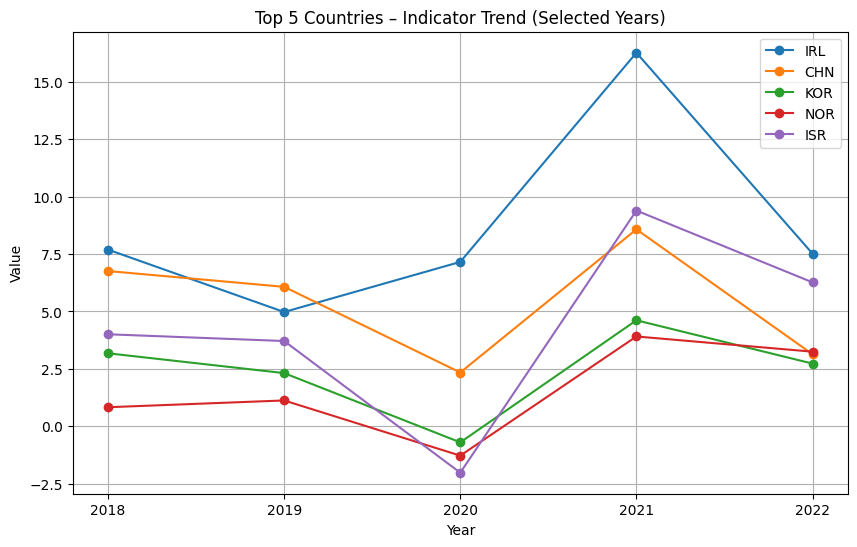

In [96]:
#Optional Plot: Top 5 Countries Over Time (Wide Format)
top5 = rank_multi_years.head(5)

plt.figure(figsize=(10,6))
for country in top5.index:
    plt.plot(years, top5.loc[country, years], marker='o', label=country)

plt.title("Top 5 Countries – Indicator Trend (Selected Years)")
plt.xlabel("Year")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()


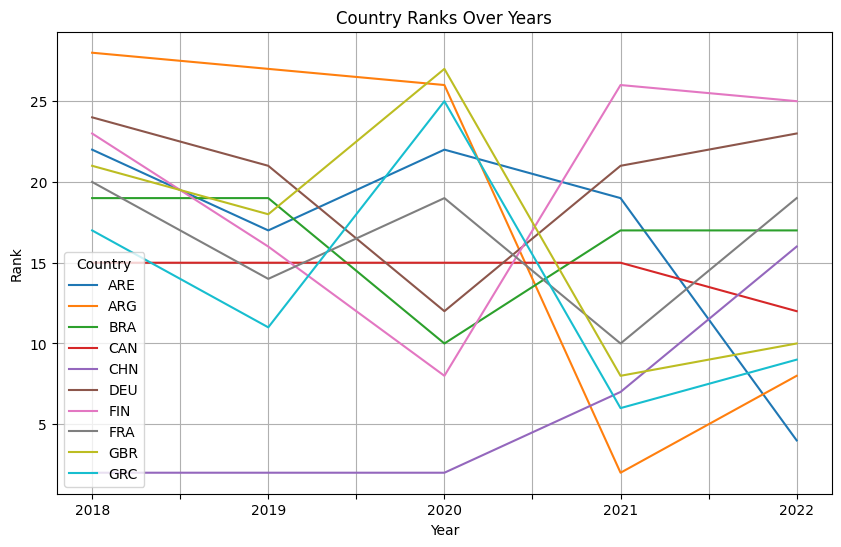

In [97]:
ranks_per_year.head(10).T.plot(figsize=(10,6))
plt.title("Country Ranks Over Years")
plt.xlabel("Year")
plt.ylabel("Rank")
plt.legend(title="Country")
plt.grid(True)
plt.show()

**Analysis  of World Bank WDI Data for India, China, and the USA**


# Analysis of World Bank WDI Data for India, China, and the USA

1.   Define target countries and indicators
2.  Compute average GDP growth over time for each country
3. Mean life expectancy per country (across all years
4. Percent change: Year-over-year growth in total population for India
5. Ranking: rank countries by CO2 emissions per capita in 2020


In [124]:
print(f"Dataset shape: {df.shape}")
print("Sample columns:", df.columns[:6].tolist())

Dataset shape: (2336, 92)
Sample columns: ['ACTION', 'FREQ', 'REF_AREA', 'INDICATOR', 'SEX', 'AGE']


In [125]:
year_pattern = r'^\d{4}$'
year_cols = df.filter(regex=year_pattern, axis=1).columns.tolist()
print("Year columns detected:", year_cols[:5], "...", year_cols[-2:])

Year columns detected: [1960, 1961, 1962, 1963, 1964] ... [2023, 2024]


In [126]:
df.rename(columns=lambda x: int(x) if isinstance(x, str) and x.isdigit() else x, inplace=True)
year_cols = [int(col) for col in year_cols]
year_cols = sorted([col for col in df.columns if isinstance(col, int)])
print("Year columns as ints:", year_cols[:5], "...", year_cols[-2:])

Year columns as ints: [1960, 1961, 1962, 1963, 1964] ... [2023, 2024]


In [127]:
# df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/WB_WDI_WIDEF.csv")
# # Define target countries and indicators

# countries = ["IND", "CHN", "USA"]

# indicators = [
#     "GDP growth (annual %)",
#     "Population, total",
#     "Life expectancy at birth, total (years)",
#     "Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)"
# ]

# df_sub = df[
#     (df["REF_AREA"].isin(countries)) &
#     (df["INDICATOR_LABEL"].isin(indicators))
# ].copy()

# display(df_sub.head())
# print("Shape:", df_sub.shape)

# df_sub.to_csv("wdi_IND_CHN_USA_selected_indicators.csv", index=False)
# # countries = ["IND", "CHN", "USA"]
# # indicators = [
# #     "GDP growth (annual %)",
# #     "Population, total",
# #     "Life expectancy at birth, total (years)",
# #     "Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)"
# # ]

df_sub = pd.read_csv("https://raw.githubusercontent.com/pankajmehta13891/Worldbank-github.io/refs/heads/main/wdi_IND_CHN_USA_selected_indicators.csv")

# # # Filter the DataFrame for these countries and indicators
# # df_sub = df[
# #     (df["REF_AREA"].isin(countries)) &
# #     (df["INDICATOR_LABEL"].isin(indicators))
# # ].copy()
print(f"Filtered rows: {df_sub.shape[0]}")
print(df_sub[["REF_AREA","INDICATOR_LABEL"]].drop_duplicates())

Filtered rows: 12
   REF_AREA                                    INDICATOR_LABEL
0       CHN  Carbon dioxide (CO2) emissions excluding LULUC...
1       CHN                              GDP growth (annual %)
2       USA                                  Population, total
3       IND                              GDP growth (annual %)
4       USA  Carbon dioxide (CO2) emissions excluding LULUC...
5       CHN                                  Population, total
6       CHN            Life expectancy at birth, total (years)
7       IND            Life expectancy at birth, total (years)
8       IND  Carbon dioxide (CO2) emissions excluding LULUC...
9       USA            Life expectancy at birth, total (years)
10      USA                              GDP growth (annual %)
11      IND                                  Population, total


In [128]:
# Pivot to wide layout with MultiIndex for demonstration (not using melt)

# The loaded df_sub already has 'level_0' and 'index' columns (likely from being saved with index=True).
# Remove these unnecessary columns before setting the desired index.
if 'level_0' in df_sub.columns and 'index' in df_sub.columns:
    df_sub = df_sub.drop(columns=['level_0', 'index'])

# Identify potential year columns in the newly loaded df_sub by checking if they are digits (strings)
df_sub_year_cols_str = [col for col in df_sub.columns if str(col).isdigit()]
# Convert these column names to integers
df_sub.rename(columns={col: int(col) for col in df_sub_year_cols_str}, inplace=True);

# Dynamically get the *actual* year columns present in df_sub after renaming
actual_df_sub_year_cols = sorted([col for col in df_sub.columns if isinstance(col, int)])

df_sub = df_sub.set_index(["REF_AREA", "INDICATOR_LABEL"])[actual_df_sub_year_cols]  # keep only existing year columns
print(df_sub.head(3))

                                                                    1960  \
REF_AREA INDICATOR_LABEL                                                   
CHN      Carbon dioxide (CO2) emissions excluding LULUCF...          NaN   
         GDP growth (annual %)                                       NaN   
USA      Population, total                                   180671000.0   

                                                                     1961  \
REF_AREA INDICATOR_LABEL                                                    
CHN      Carbon dioxide (CO2) emissions excluding LULUCF...           NaN   
         GDP growth (annual %)                              -2.727000e+01   
USA      Population, total                                   1.836910e+08   

                                                                     1962  \
REF_AREA INDICATOR_LABEL                                                    
CHN      Carbon dioxide (CO2) emissions excluding LULUCF...           NaN   
  

In [129]:
# Ranking: rank countries by CO2 emissions per capita in 2020
co2 = df_sub.xs("Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)", level="INDICATOR_LABEL")
rank2020 = co2[2020].rank(ascending=False)
print(rank2020)

REF_AREA
CHN    2.0
USA    1.0
IND    3.0
Name: 2020, dtype: float64


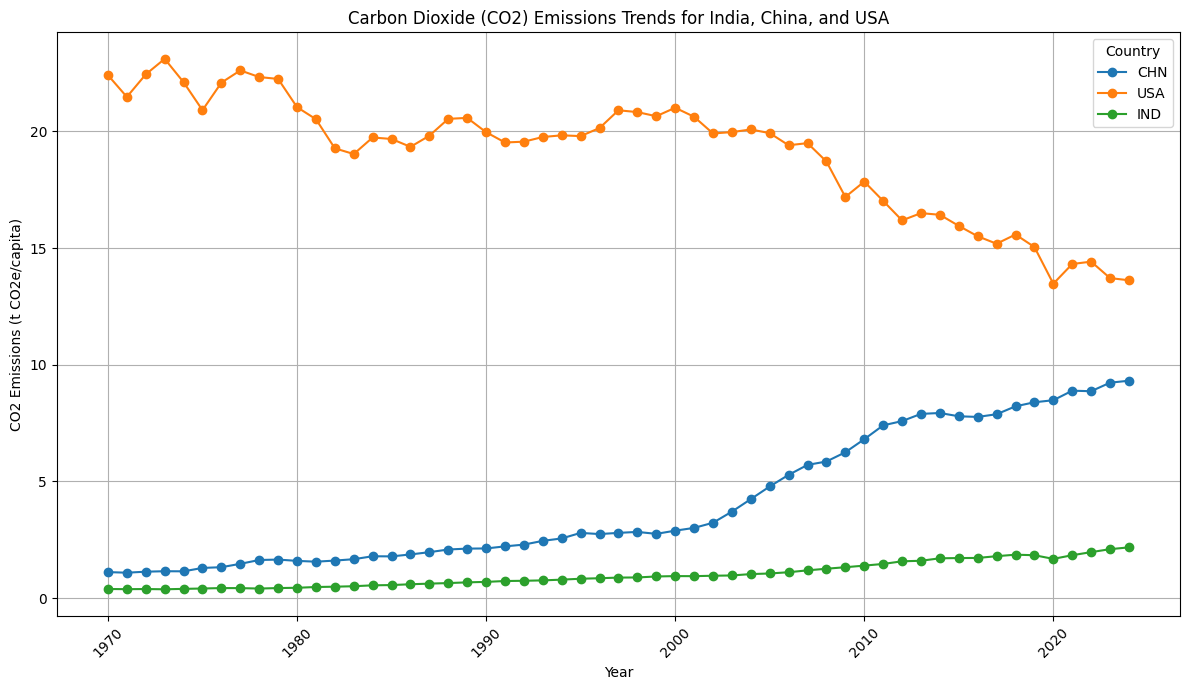

In [130]:
import matplotlib.pyplot as plt
import pandas as pd # Ensure pandas is imported

# The error indicates df_sub is not a MultiIndex DataFrame.
# This often happens if a cell that sets the MultiIndex was not run or was overwritten.
# We will ensure df_sub has the correct MultiIndex structure here.

# Reload df_sub from the source to get its initial state (flat DataFrame)
df_sub = pd.read_csv("https://raw.githubusercontent.com/pankajmehta13891/Worldbank-github.io/refs/heads/main/wdi_IND_CHN_USA_selected_indicators.csv")

# Clean up any residual index columns that might have been saved in the CSV
if 'level_0' in df_sub.columns and 'index' in df_sub.columns:
    df_sub = df_sub.drop(columns=['level_0', 'index'])

# Convert year columns (which are strings after reading CSV) to integers
df_sub_year_cols_str = [col for col in df_sub.columns if str(col).isdigit()]
df_sub.rename(columns={col: int(col) for col in df_sub_year_cols_str}, inplace=True)

# Get the actual year columns as integers
actual_df_sub_year_cols = sorted([col for col in df_sub.columns if isinstance(col, int)])

# Set the MultiIndex
df_sub = df_sub.set_index(["REF_AREA", "INDICATOR_LABEL"])[actual_df_sub_year_cols]

# Now that df_sub is a MultiIndex, we can safely use .xs
co2 = df_sub.xs("Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)", level="INDICATOR_LABEL")

plt.figure(figsize=(12, 7))
co2.T.plot(ax=plt.gca(), marker='o', linestyle='-')
plt.title('Carbon Dioxide (CO2) Emissions Trends for India, China, and USA')
plt.xlabel('Year')
plt.ylabel('CO2 Emissions (t CO2e/capita)')
plt.grid(True)
plt.legend(title='Country')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [131]:
# Example: Compute average GDP growth over time for each country
gdp = df_sub.xs("GDP growth (annual %)", level="INDICATOR_LABEL") # select GDP
gdp_mean_by_country = gdp.mean(axis=1).sort_values(ascending=False)
print("Average GDP growth (%):")
print(gdp_mean_by_country)

Average GDP growth (%):
REF_AREA
CHN    7.920939
IND    5.241188
USA    3.015674
dtype: float64


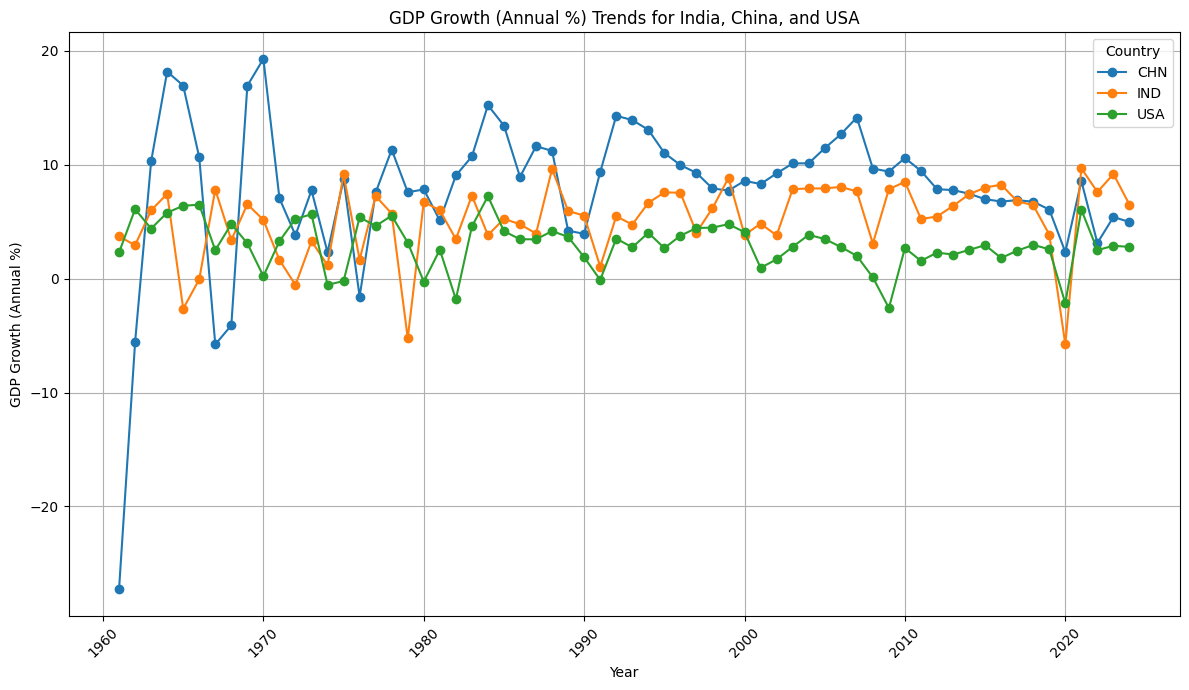

In [132]:
import matplotlib.pyplot as plt
import pandas as pd

# The df_sub DataFrame needs to be a MultiIndex DataFrame for .xs to work.
# Ensure df_sub is loaded and transformed correctly within this cell.

# Reload df_sub from the source to get its initial state (flat DataFrame)
df_sub = pd.read_csv("https://raw.githubusercontent.com/pankajmehta13891/Worldbank-github.io/refs/heads/main/wdi_IND_CHN_USA_selected_indicators.csv")

# Clean up any residual index columns that might have been saved in the CSV
if 'level_0' in df_sub.columns and 'index' in df_sub.columns:
    df_sub = df_sub.drop(columns=['level_0', 'index'])

# Convert year columns (which are strings after reading CSV) to integers
df_sub_year_cols_str = [col for col in df_sub.columns if str(col).isdigit()]
df_sub.rename(columns={col: int(col) for col in df_sub_year_cols_str}, inplace=True)

# Get the actual year columns as integers
actual_df_sub_year_cols = sorted([col for col in df_sub.columns if isinstance(col, int)])

# Set the MultiIndex
df_sub = df_sub.set_index(["REF_AREA", "INDICATOR_LABEL"])[actual_df_sub_year_cols]

# Now that df_sub is a MultiIndex, we can safely use .xs
gdp = df_sub.xs("GDP growth (annual %)", level="INDICATOR_LABEL")

plt.figure(figsize=(12, 7))
gdp.T.plot(ax=plt.gca(), marker='o', linestyle='-')
plt.title('GDP Growth (Annual %) Trends for India, China, and USA')
plt.xlabel('Year')
plt.ylabel('GDP Growth (Annual %)')
plt.grid(True)
plt.legend(title='Country')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [133]:
# GroupBy example: Mean life expectancy per country (across all years)
life = df_sub.xs("Life expectancy at birth, total (years)", level="INDICATOR_LABEL")
life_mean = life.mean(axis=1).sort_values()
print("\nMean Life Expectancy (years):")
print(life_mean)


Mean Life Expectancy (years):
REF_AREA
IND    58.652172
CHN    66.990781
USA    74.961280
dtype: float64


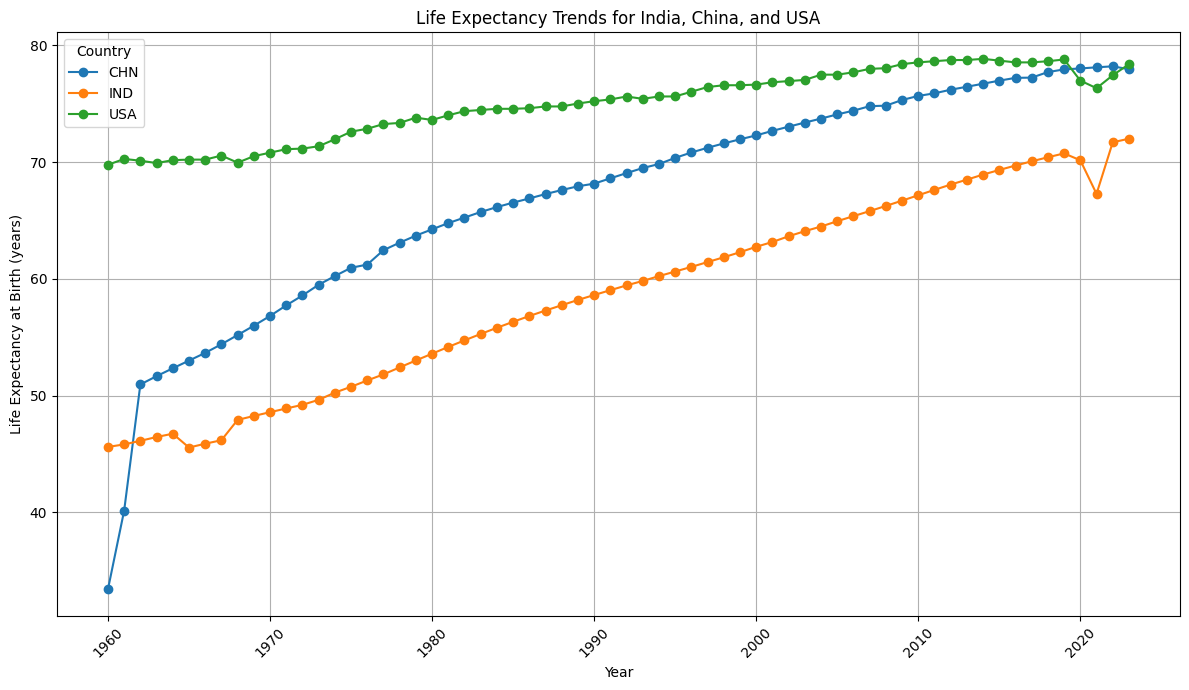

In [134]:
import matplotlib.pyplot as plt

# 'life' DataFrame already contains life expectancy data for IND, CHN, USA
# from a previous step: life = df_sub.xs("Life expectancy at birth, total (years)", level="INDICATOR_LABEL")

plt.figure(figsize=(12, 7))
life.T.plot(ax=plt.gca(), marker='o', linestyle='-')
plt.title('Life Expectancy Trends for India, China, and USA')
plt.xlabel('Year')
plt.ylabel('Life Expectancy at Birth (years)')
plt.grid(True)
plt.legend(title='Country')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [135]:
# Percent change: Year-over-year growth in total population for India
pop = df_sub.xs("Population, total", level="INDICATOR_LABEL")
pop_india = pop.loc["IND"].T # transpose: index=year, values=population
pop_india_pct = pop_india.pct_change() * 100
print("\nPopulation % change (India) in 5-year steps:")
print(pop_india_pct.dropna().iloc[::5]) # show every 5th year for brevity


Population % change (India) in 5-year steps:
1961    2.425373
1966    2.162667
1971    2.240872
1976    2.380520
1981    2.377556
1986    2.335111
1991    2.191444
1996    2.017848
2001    1.888214
2006    1.576422
2011    1.426912
2016    1.198758
2021    0.826041
Name: IND, dtype: float64


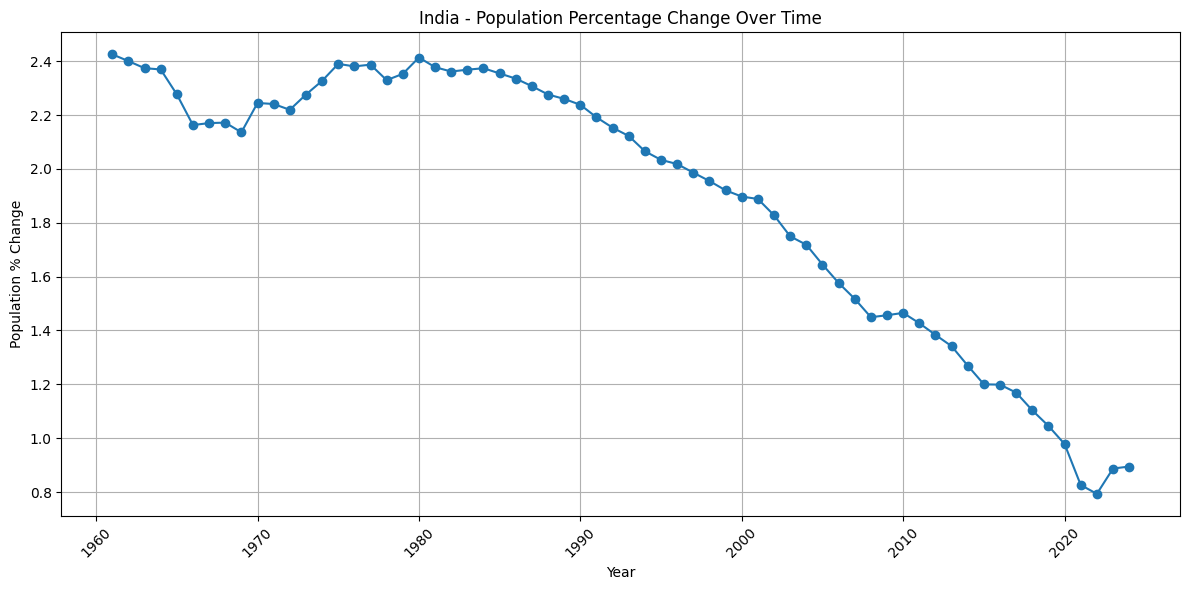

In [136]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
pop_india_pct.plot(marker='o', linestyle='-')
plt.title('India - Population Percentage Change Over Time')
plt.xlabel('Year')
plt.ylabel('Population % Change')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [137]:
# We already set a MultiIndex above: ensure it is sorted for clarity
df_multi = df_sub.sort_index()
print(df_multi.head())

                                                                     1960  \
REF_AREA INDICATOR_LABEL                                                    
CHN      Carbon dioxide (CO2) emissions excluding LULUCF...           NaN   
         GDP growth (annual %)                                        NaN   
         Life expectancy at birth, total (years)             3.341900e+01   
         Population, total                                   6.670700e+08   
IND      Carbon dioxide (CO2) emissions excluding LULUCF...           NaN   

                                                                     1961  \
REF_AREA INDICATOR_LABEL                                                    
CHN      Carbon dioxide (CO2) emissions excluding LULUCF...           NaN   
         GDP growth (annual %)                              -2.727000e+01   
         Life expectancy at birth, total (years)             4.015800e+01   
         Population, total                                   6.603300e+08  

In [138]:
df_sub.xs("Population, total", level="INDICATOR_LABEL")

,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
REF_AREA,,,,,,,,,,,,,,,,,,,,,
USA,180671000.0,183691000.0,186538000.0,189242000.0,191889000.0,194303000.0,196560000.0,198712000.0,200706000.0,202677000.0,...,3.218151e+08,3.243533e+08,3.266086e+08,3.285296e+08,3.302262e+08,3.315777e+08,3.320998e+08,3.340173e+08,3.368062e+08,3.401110e+08
CHN,667070000.0,660330000.0,665770000.0,682335000.0,698355000.0,715185000.0,735400000.0,754550000.0,774510000.0,796025000.0,...,1.379860e+09,1.387790e+09,1.396215e+09,1.402760e+09,1.407745e+09,1.411100e+09,1.412360e+09,1.412175e+09,1.410710e+09,1.408975e+09
IND,435990338.0,446564729.0,457283090.0,468138575.0,479229598.0,490140146.0,500740247.0,511606372.0,522716889.0,533880544.0,...,1.328024e+09,1.343944e+09,1.359657e+09,1.374659e+09,1.389030e+09,1.402618e+09,1.414204e+09,1.425423e+09,1.438070e+09,1.450936e+09


In [139]:
df_sub.sort_values(by=2022, ascending=False).head()

,,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
REF_AREA,INDICATOR_LABEL,,,,,,,,,,,,,,,,,,,,,
IND,"Population, total",4.359903e+08,4.465647e+08,4.572831e+08,4.681386e+08,4.792296e+08,4.901401e+08,5.007402e+08,5.116064e+08,5.227169e+08,5.338805e+08,...,1.328024e+09,1.343944e+09,1.359657e+09,1.374659e+09,1.389030e+09,1.402618e+09,1.414204e+09,1.425423e+09,1.438070e+09,1.450936e+09
CHN,"Population, total",6.670700e+08,6.603300e+08,6.657700e+08,6.823350e+08,6.983550e+08,7.151850e+08,7.354000e+08,7.545500e+08,7.745100e+08,7.960250e+08,...,1.379860e+09,1.387790e+09,1.396215e+09,1.402760e+09,1.407745e+09,1.411100e+09,1.412360e+09,1.412175e+09,1.410710e+09,1.408975e+09
USA,"Population, total",1.806710e+08,1.836910e+08,1.865380e+08,1.892420e+08,1.918890e+08,1.943030e+08,1.965600e+08,1.987120e+08,2.007060e+08,2.026770e+08,...,3.218151e+08,3.243533e+08,3.266086e+08,3.285296e+08,3.302262e+08,3.315777e+08,3.320998e+08,3.340173e+08,3.368062e+08,3.401110e+08
CHN,"Life expectancy at birth, total (years)",3.341900e+01,4.015800e+01,5.095900e+01,5.167000e+01,5.234300e+01,5.300100e+01,5.366200e+01,5.440100e+01,5.519100e+01,5.598800e+01,...,7.697500e+01,7.721400e+01,7.723500e+01,7.770900e+01,7.794000e+01,7.801900e+01,7.811700e+01,7.820200e+01,7.795300e+01,NaN
USA,"Life expectancy at birth, total (years)",6.977073e+01,7.027073e+01,7.011951e+01,6.991707e+01,7.016585e+01,7.021463e+01,7.021220e+01,7.056098e+01,6.995122e+01,7.050732e+01,...,7.869024e+01,7.853902e+01,7.853902e+01,7.863902e+01,7.878780e+01,7.698049e+01,7.632927e+01,7.743415e+01,7.838537e+01,NaN


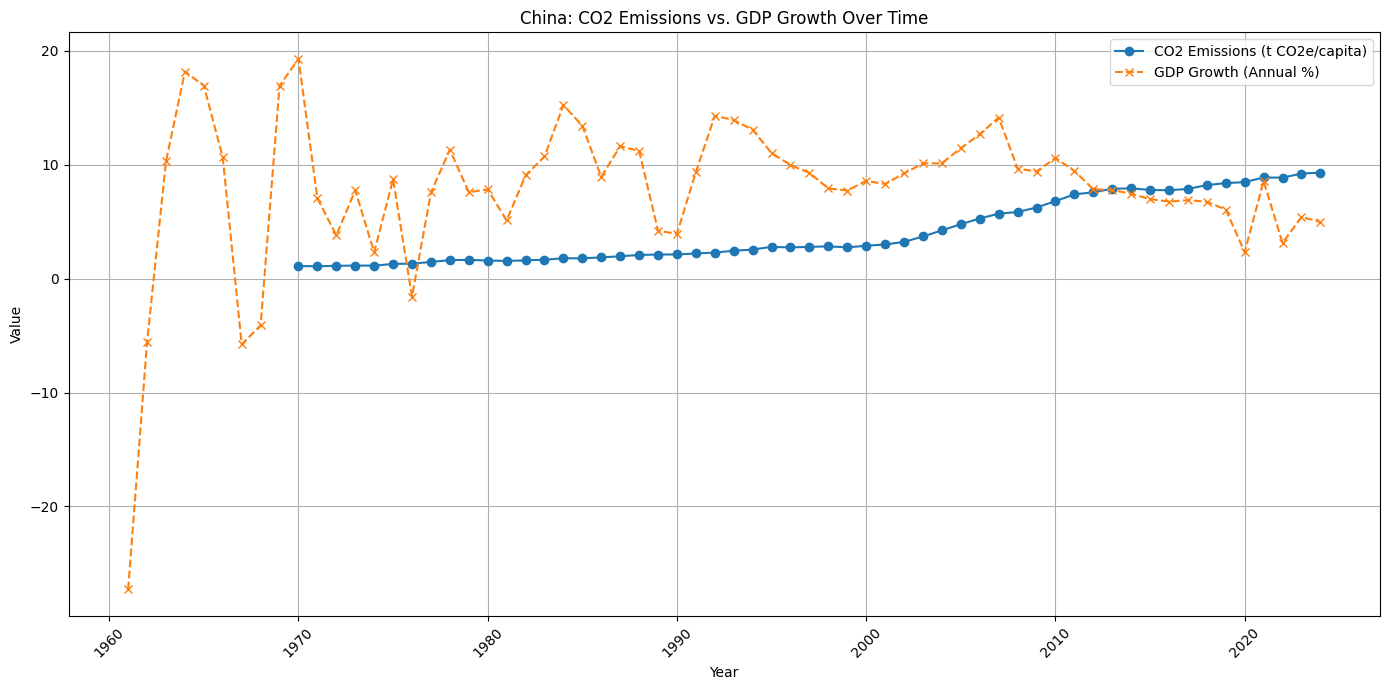

In [140]:
import matplotlib.pyplot as plt

# Extract China's CO2 emissions data
china_co2 = df_sub.xs("Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)", level="INDICATOR_LABEL").loc["CHN"]

# Extract China's GDP growth data
china_gdp = df_sub.xs("GDP growth (annual %)", level="INDICATOR_LABEL").loc["CHN"]

plt.figure(figsize=(14, 7))

# Plot CO2 Emissions
plt.plot(china_co2.index, china_co2.values, label='CO2 Emissions (t CO2e/capita)', marker='o', linestyle='-')

# Plot GDP Growth
plt.plot(china_gdp.index, china_gdp.values, label='GDP Growth (Annual %)', marker='x', linestyle='--')

plt.title('China: CO2 Emissions vs. GDP Growth Over Time')
plt.xlabel('Year')
plt.ylabel('Value')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [141]:
df_sub.loc['CHN']

,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
INDICATOR_LABEL,,,,,,,,,,,,,,,,,,,,,
Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.790570e+00,7.763225e+00,7.878027e+00,8.217736e+00,8.391476e+00,8.478583e+00,8.887157e+00,8.864825e+00,9.230276e+00,9.315089e+00
GDP growth (annual %),NaN,-2.727000e+01,-5.580000e+00,1.030000e+01,1.818000e+01,1.695000e+01,1.065000e+01,-5.770000e+00,-4.100000e+00,1.694000e+01,...,6.978780e+00,6.775556e+00,6.891266e+00,6.756718e+00,6.068502e+00,2.340188e+00,8.570085e+00,3.134189e+00,5.414843e+00,4.977357e+00
"Population, total",6.670700e+08,6.603300e+08,6.657700e+08,6.823350e+08,6.983550e+08,7.151850e+08,7.354000e+08,7.545500e+08,7.745100e+08,7.960250e+08,...,1.379860e+09,1.387790e+09,1.396215e+09,1.402760e+09,1.407745e+09,1.411100e+09,1.412360e+09,1.412175e+09,1.410710e+09,1.408975e+09
"Life expectancy at birth, total (years)",3.341900e+01,4.015800e+01,5.095900e+01,5.167000e+01,5.234300e+01,5.300100e+01,5.366200e+01,5.440100e+01,5.519100e+01,5.598800e+01,...,7.697500e+01,7.721400e+01,7.723500e+01,7.770900e+01,7.794000e+01,7.801900e+01,7.811700e+01,7.820200e+01,7.795300e+01,NaN


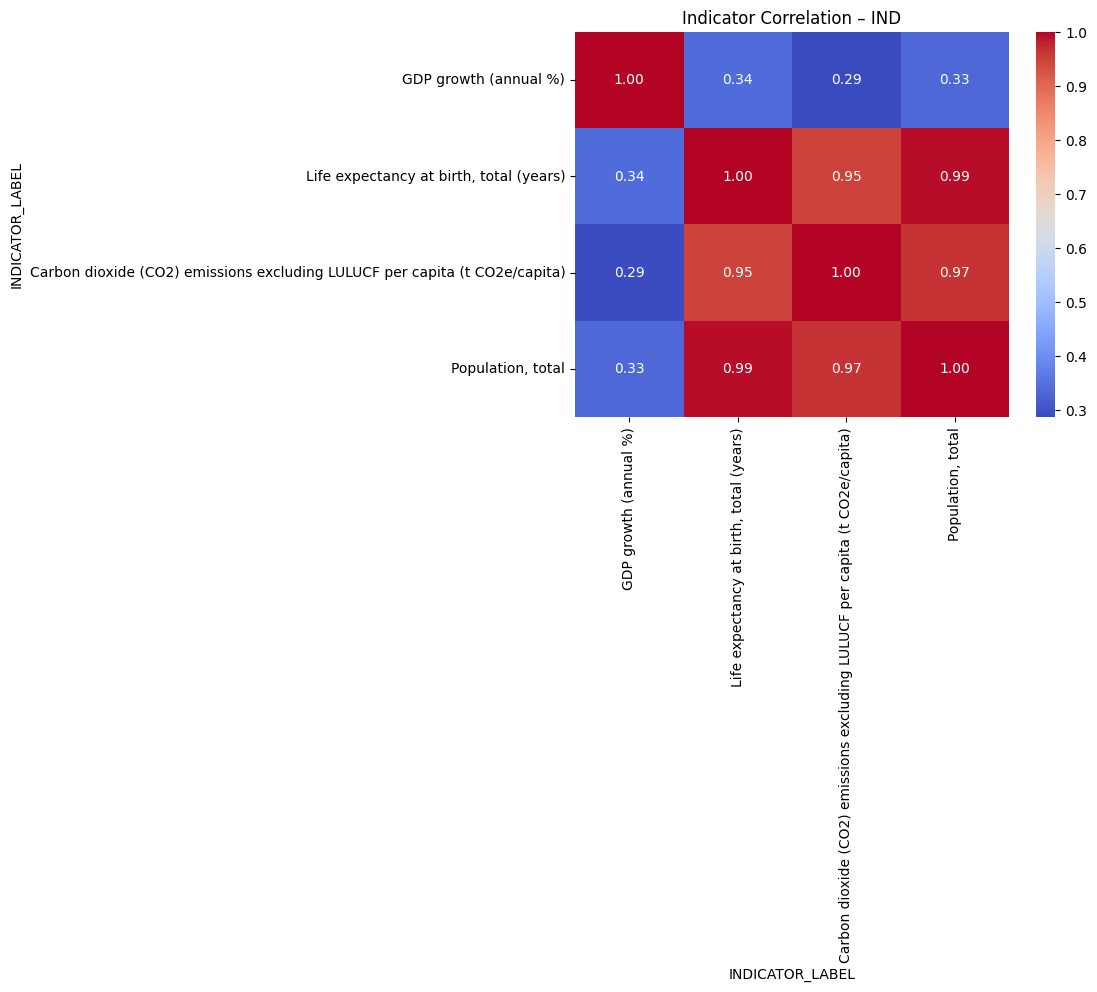

In [142]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_correlation(country_code):
    # Filter df_sub where 'REF_AREA' index level matches country_code
    # df_sub has REF_AREA as the first level of its MultiIndex
    country_data = df_sub.loc[country_code]

    # country_data now has INDICATOR_LABEL as its index and year columns as its columns
    # No need for further set_index or year_cols_int filtering on columns, as they are already the integer years
    country_df = country_data

    corr = country_df.T.corr()              # rows = years → correlation across indicators

    plt.figure(figsize=(7,5))
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title(f"Indicator Correlation – {country_code}")
    plt.show()

plot_correlation("IND")

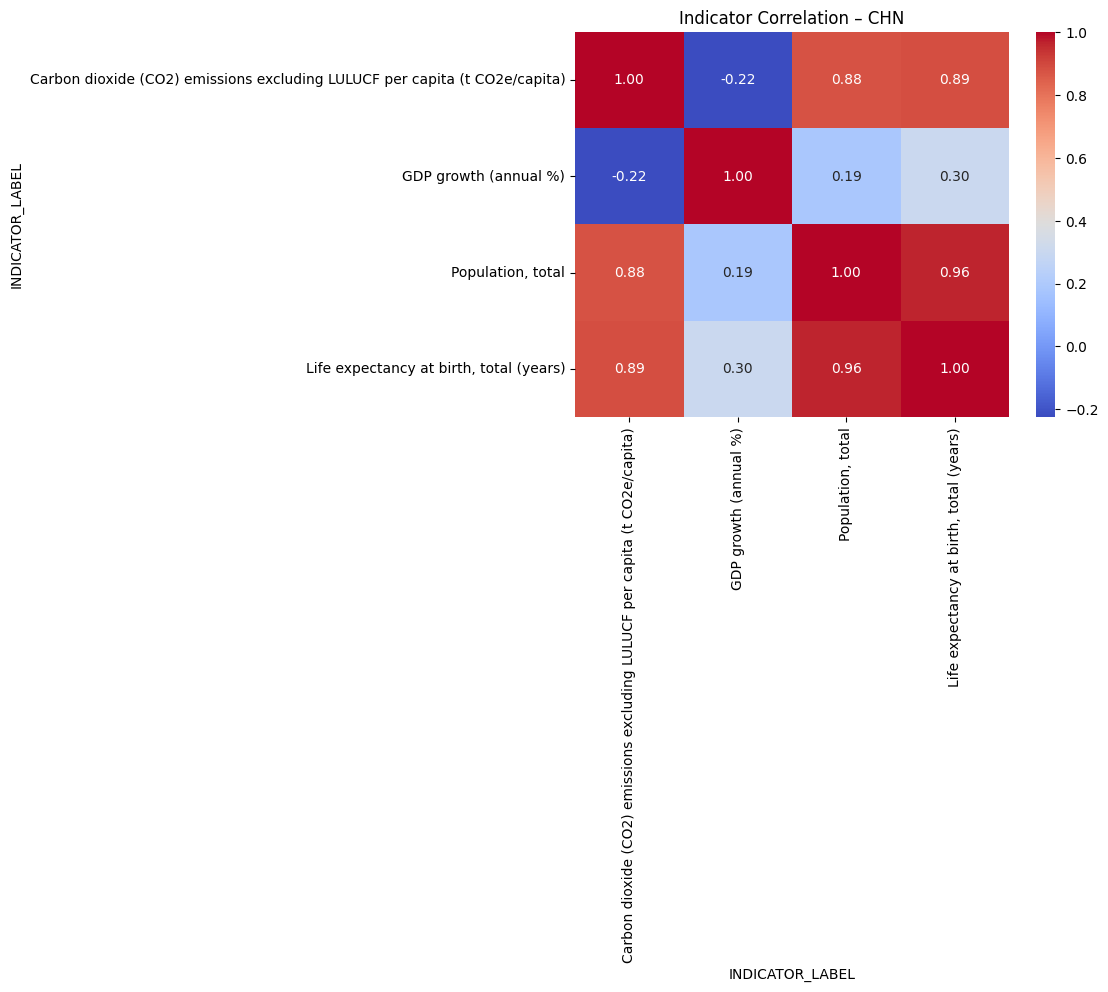

In [143]:
plot_correlation("CHN")


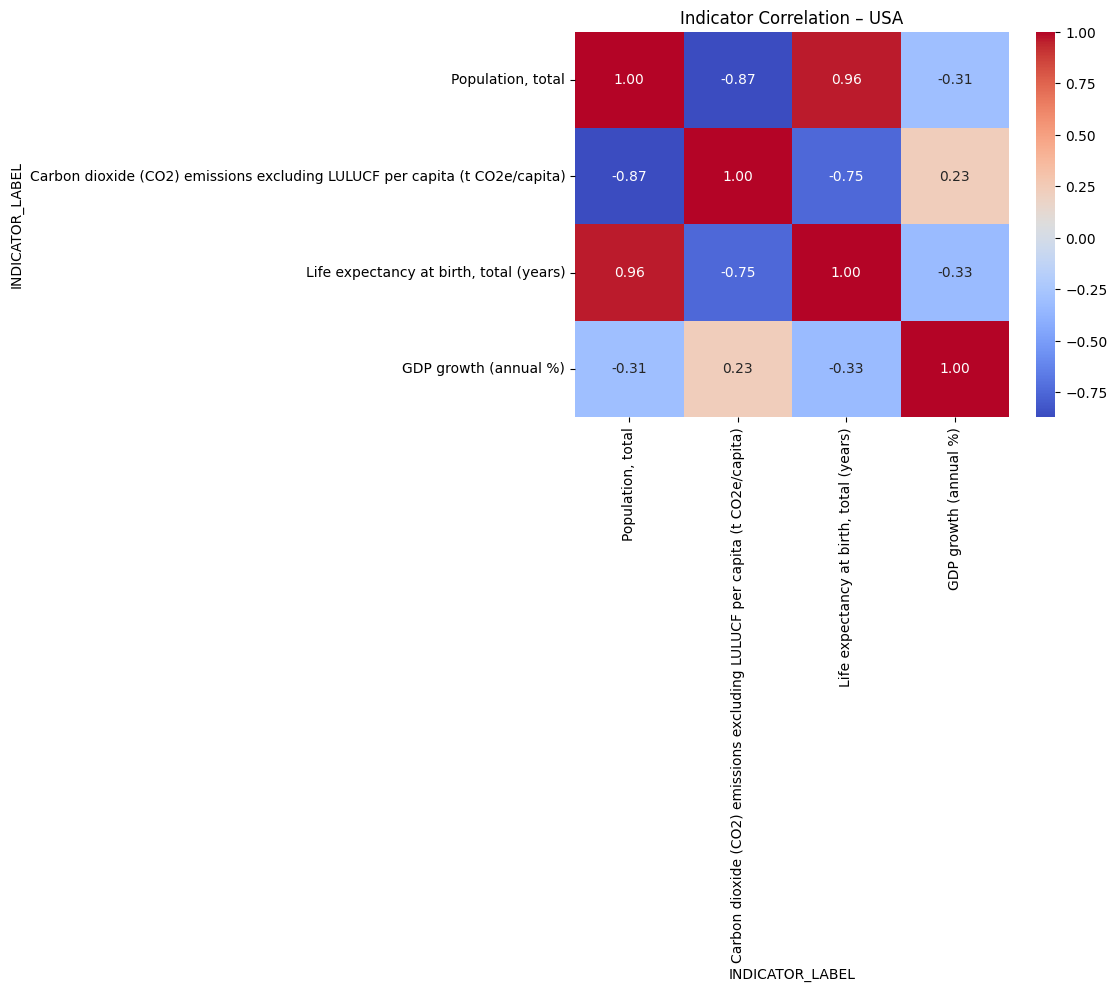

In [144]:
plot_correlation("USA")

In [145]:
# Combine multiple indicators into one wide table per country
df_wide = df_multi.unstack(level="INDICATOR_LABEL")
df_wide.columns = df_wide.columns.swaplevel(0,1)  # make (Indicator, Year) to (Year, Indicator)
df_wide = df_wide.sort_index(axis=1, level=0)
print(df_wide.head())

INDICATOR_LABEL Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)  \
                                                                                      1960   
REF_AREA                                                                                     
CHN                                                            NaN                           
IND                                                            NaN                           
USA                                                            NaN                           

INDICATOR_LABEL                                               ...  \
                1961 1962 1963 1964 1965 1966 1967 1968 1969  ...   
REF_AREA                                                      ...   
CHN              NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...   
IND              NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...   
USA              NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...   

INDICATOR_LABEL Popu

In [146]:
df_wide

INDICATOR_LABEL Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)  \
                                                                                      1960   
REF_AREA                                                                                     
CHN                                                            NaN                           
IND                                                            NaN                           
USA                                                            NaN                           

INDICATOR_LABEL                                               ...  \
                1961 1962 1963 1964 1965 1966 1967 1968 1969  ...   
REF_AREA                                                      ...   
CHN              NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...   
IND              NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...   
USA              NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...   

INDICATOR_LABEL Population, total                                            \
                             2015          2016          2017          2018   
REF_AREA                                                                      
CHN                  1.379860e+09  1.387790e+09  1.396215e+09  1.402760e+09   
IND                  1.328024e+09  1.343944e+09  1.359657e+09  1.374659e+09   
USA                  3.218151e+08  3.243533e+08  3.266086e+08  3.285296e+08   

INDICATOR_LABEL                                                          \
                         2019          2020          2021          2022   
REF_AREA                                                                  
CHN              1.407745e+09  1.411100e+09  1.412360e+09  1.412175e+09   
IND              1.389030e+09  1.402618e+09  1.414204e+09  1.425423e+09   
USA              3.302262e+08  3.315777e+08  3.320998e+08  3.340173e+08   

INDICATOR_LABEL                              
                         2023          2024  
REF_AREA                                     
CHN              1.410710e+09  1.408975e+09  
IND              1.438070e+09  1.450936e+09  
USA              3.368062e+08  3.401110e+08  

[3 rows x 260 columns]